In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from jax import custom_derivatives, dtypes, lax
from jax._src.lax.lax import _const as _lax_const
from jax._src.numpy.util import promote_args_inexact, promote_dtypes_inexact
from jax.typing import ArrayLike
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Functions

In [2]:
def digitize_equiprobable(data, N):
    """
    Coarse-grain continuous data into N equiprobable bins (quantile-based).
    Each sample is replaced by the bin's representative (mean) value.

    Parameters:
        data (array-like): input float data (any shape)
        N (int): number of bins

    Returns:
        np.ndarray: data replaced by bin representative values
        np.ndarray: bin edges used
    """
    data = jnp.asarray(data)

    # Compute quantile-based bin edges
    quantiles = jnp.linspace(0, 1, N + 1)
    bin_edges = jnp.quantile(
        data, quantiles, axis=1
    ).T  # jnp.linspace(data.min(axis=1), data.max(axis=1), N).T#

    bin_idx = jax.vmap(jnp.digitize, in_axes=(0, 0, None))(data, bin_edges, True)

    return bin_idx, bin_edges

In [3]:
def xlogy(x: ArrayLike, y: ArrayLike):
    """Compute x*log(y), returning 0 for x=0.

    JAX implementation of :obj:`scipy.special.xlogy`.

    This is defined to return zero when :math:`(x, y) = (0, 0)`, with a custom
    derivative rule so that automatic differentiation is well-defined at this point.

    Args:
      x: arraylike, real-valued.
      y: arraylike, real-valued.

    Returns:
      array containing xlogy values.

    See also:
      :func:`jax.scipy.special.xlog1py`
    """
    # Note: xlogy(0, 0) should return 0 according to the function documentation.
    x, y = promote_args_inexact("xlogy", x, y)
    x_ok = x != 0.0
    return jnp.where(x_ok, lax.mul(x, lax.log(y)), jnp.zeros_like(x))


def entrBin(x: ArrayLike, deltas: ArrayLike):
    r"""The entropy function

  JAX implementation of :obj:`scipy.special.entr`.

  .. math::

     \mathrm{entr}(x) = \begin{cases}
       -x\log(x) & x > 0 \\
       0 & x = 0\\
       -\infty & \mathrm{otherwise}
     \end{cases}

  Args:
    x: arraylike, real-valued.

  Returns:
    array containing entropy values.

  See also:
    - :func:`jax.scipy.special.kl_div`
    - :func:`jax.scipy.special.rel_entr`
  """
    (x,) = promote_args_inexact("entr", x)
    if dtypes.issubdtype(x.dtype, np.complexfloating):
        raise ValueError("entr does not support complex-valued inputs.")
    return lax.select(
        lax.lt(x, _lax_const(x, 0)),
        lax.full_like(x, -np.inf),
        lax.neg(xlogy(x, x / deltas)),
    )

In [1]:
def entropyBin(x, N, n_bins, deltas):

    # Entropy
    uniques, counts = jnp.unique(x, return_counts=True, axis=1, size=N, fill_value=0)
    probs = counts / N

    n_states = uniques.shape[0]

    delta_per_state = jnp.prod(
        deltas[jnp.arange(deltas.shape[0])[:, None], uniques], axis=0
    )
    return entrBin(probs, delta_per_state).sum() / jnp.log(2)


def mutualInformationBin(x, y, nx_bins, ny_bins):

    x, bin_edges_x = digitize_equiprobable(x, nx_bins)
    y, bin_edges_y = digitize_equiprobable(y, ny_bins)

    N = x.shape[1]

    delta_bin_x = jnp.diff(bin_edges_x, axis=1)
    delta_bin_y = jnp.diff(bin_edges_y, axis=1)

    delta_bin_x = jnp.atleast_2d(delta_bin_x)
    delta_bin_y = jnp.atleast_2d(delta_bin_y)

    Hx = entropyBin(x, N, nx_bins, delta_bin_x)
    Hy = entropyBin(y, N, ny_bins, delta_bin_y)

    Hxy = entropyBin(
        jnp.concatenate((x, y), axis=0),
        N,
        ny_bins * nx_bins,
        jnp.concatenate((delta_bin_x, delta_bin_y), axis=0),
    )
    return Hx + Hy - Hxy


mutualInformationBin_jax = jax.vmap(mutualInformationBin, in_axes=(2, 2, None, None))

NameError: name 'jax' is not defined

In [5]:
def entropy_gauss(sigma: float) -> float:
    return (0.5 * np.log(2 * np.pi * np.e * sigma**2)) / np.log(2)

In [6]:
def entropy_gauss_mv(sigma: float, D: int) -> float:
    return (
        0.5 * np.log(np.linalg.det(sigma)) + D / 2 * (1 + np.log(2 * np.pi))
    ) / np.log(2)

In [7]:
def mi_gaussian_rho(rho):
    return -0.5 * np.log2(1 - rho**2)

In [8]:
import numpy as np


def mi_gauss_mv(Sigma_xx, Sigma_yy, Sigma_xy):
    """Analytical MI (bits) for multivariate Gaussian."""
    Sigma = np.block([[Sigma_xx, Sigma_xy], [Sigma_xy.T, Sigma_yy]])
    det_xx = np.linalg.det(Sigma_xx)
    det_yy = np.linalg.det(Sigma_yy)
    det_full = np.linalg.det(Sigma)
    return 0.5 * np.log2((det_xx * det_yy) / det_full)

#### Entropy (univariate)

In [9]:
N = 50_000

In [10]:
n_bins_list = np.arange(2, 50, 1)

res = []

for n_bins in tqdm(n_bins_list):

    x = np.random.normal(0, 1, size=(1, N))

    x, bin_edges_x = digitize_equiprobable(x, n_bins)

    delta_bin_x = jnp.diff(bin_edges_x, axis=1)

    res.append(entropyBin(x, N, n_bins, delta_bin_x))

100%|███████████████████████████████████| 48/48 [00:06<00:00,  7.47it/s]


(2.0, 49.0)

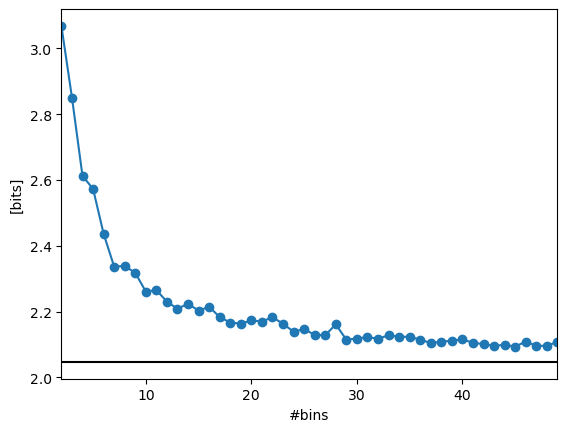

In [11]:
plt.plot(n_bins_list, res, "o-")
plt.hlines(entropy_gauss(1), n_bins_list.min(), n_bins_list.max(), "k")
plt.ylabel("[bits]")
plt.xlabel("#bins")
plt.xlim(n_bins_list.min(), n_bins_list.max())

#### Entropy (multi-univariate)

In [12]:
n_bins_list = np.arange(2, 50, 1)

res = []

for n_bins in tqdm(n_bins_list):

    x = np.random.normal(0, 1, size=(2, N))

    x, bin_edges_x = digitize_equiprobable(x, n_bins)

    delta_bin_x = jnp.diff(bin_edges_x, axis=1)

    delta_bin_x = jnp.atleast_2d(delta_bin_x)

    res.append(entropyBin(x, N, n_bins, delta_bin_x))

100%|███████████████████████████████████| 48/48 [00:06<00:00,  7.41it/s]


(2.0, 49.0)

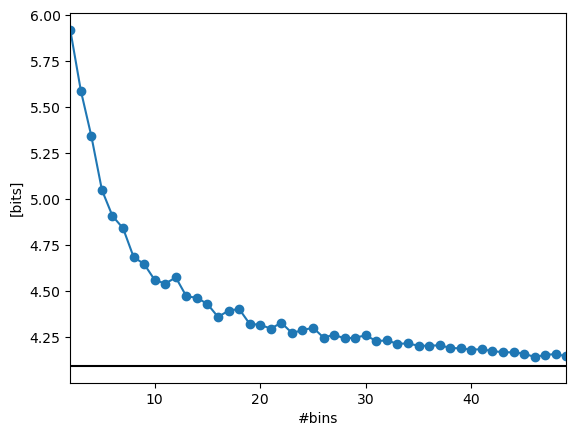

In [13]:
plt.plot(n_bins_list, res, "o-")
plt.hlines(entropy_gauss_mv(np.eye(2), 2), n_bins_list.min(), n_bins_list.max(), "k")
plt.ylabel("[bits]")
plt.xlabel("#bins")
plt.xlim(n_bins_list.min(), n_bins_list.max())

#### Mutual information (single feature)

In [14]:
cov_list = np.arange(0, 1, 0.05)

MI = []
MI_EX = []

for cov in tqdm(cov_list):

    x = np.random.multivariate_normal(
        mean=[0, 0], cov=[[1, cov], [cov, 1]], size=(1, N)
    )

    MI += [mutualInformationBin(x[..., 0], x[..., 1], 50, 50)]
    MI_EX += [mi_gaussian_rho(cov)]  # [mi_gaussian_rho(cov)]

100%|███████████████████████████████████| 20/20 [00:01<00:00, 16.49it/s]


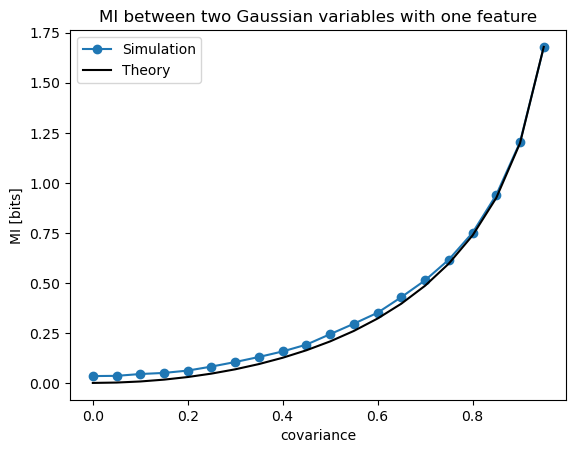

In [15]:
plt.plot(cov_list, MI, "o-", label="Simulation")
plt.plot(cov_list, MI_EX, "k-", label="Theory")

plt.ylabel("MI [bits]")
plt.xlabel("covariance")
plt.title("MI between two Gaussian variables with one feature")
plt.legend()

#### Mutual information (multi feature)

In [16]:
cov_list = np.arange(0, 1, 0.05)
MI = []
MI_EX = []
RHO = []

for cov in tqdm(cov_list):
    Sigma_xx = np.eye(2)
    Sigma_yy = np.eye(2)
    Sigma_xy = cov * np.eye(2)
    Sigma = np.block([[Sigma_xx, Sigma_xy], [Sigma_xy.T, Sigma_yy]])
    data = np.random.multivariate_normal(np.zeros(4), Sigma, size=N)
    x = data[:, :2].T
    y = data[:, 2:].T
    MI.append(mutualInformationBin(x, y, 10, 10))
    MI_EX.append(mi_gauss_mv(Sigma_xx, Sigma_yy, Sigma_xy))
    RHO += [np.corrcoef(x.flatten(), y.flatten())[0, 1]]

100%|███████████████████████████████████| 20/20 [00:03<00:00,  5.42it/s]


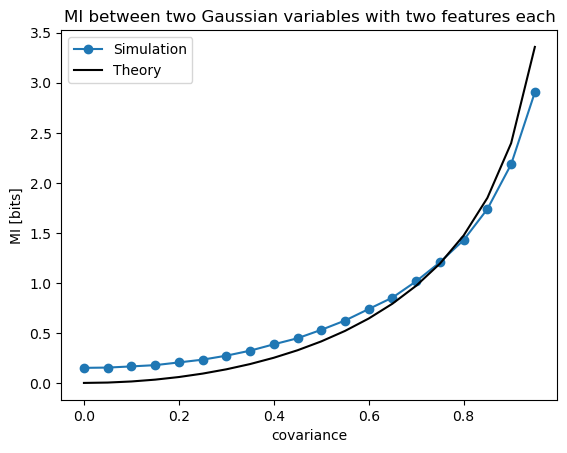

In [17]:
plt.plot(cov_list, MI, "o-", label="Simulation")
plt.plot(cov_list, MI_EX, "k-", label="Theory")

plt.ylabel("MI [bits]")
plt.xlabel("covariance")
plt.title("MI between two Gaussian variables with two features each")
plt.legend()